# Demographics

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from datetime import datetime

# visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# geospatial manipulation
import cartopy.crs as ccrs

from src.data_fetching.fusion_energy_base import (
    get_fusion_machine_developers,
    get_research_organizations,
    aggregate_data,
)
from src.data_fetching.google_analytics import (
    users_city,
    users_world,
    engagement_time_per_active_user,
)
from src.geospatial.geocoding import find_locations_from_cache
from src.plotting.maps import plot_europe, plot_locations

In [2]:
proj = ccrs.Mercator()

url = "https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/all_world.geojson"
world = gpd.read_file(url)
world = world[~world["name"].isin(["Antarctica", "Greenland"])]
world = world.to_crs(proj.proj4_init)

In [3]:
fusion_machine_developers_data = aggregate_data(get_fusion_machine_developers())
research_organizations_data = aggregate_data(get_research_organizations())

locations_orgs = find_locations_from_cache(
    research_organizations_data, "locations_cache.geojson"
)
locations_fusion_developers = find_locations_from_cache(
    fusion_machine_developers_data, "locations_cache.geojson"
)

In [4]:
start_date_ga = datetime(2026, 1, 14)
end_date_ga = datetime.today()
FESTIM_DOCS_ID = "521295665"
FESTIM_TUTO_ID = "521287230"

response = users_city(start_date_ga, end_date_ga, FESTIM_DOCS_ID)
df_users = pd.DataFrame(
    {
        "city": [row.dimension_values[0].value for row in response.rows],
        "activeUsers": [int(row.metric_values[0].value) for row in response.rows],
    }
)
df_users = df_users[df_users["city"] != "(not set)"]
locations_users = find_locations_from_cache(
    df_users, "locations_cache.geojson", update_cache=True
)
response_countries = users_world(start_date_ga, end_date_ga, FESTIM_DOCS_ID)
df_users_countries = pd.DataFrame(
    {
        "country": [row.dimension_values[0].value for row in response_countries.rows],
        "activeUsers": [
            int(row.metric_values[0].value) for row in response_countries.rows
        ],
    }
)

response_tutorials = engagement_time_per_active_user(
    start_date_ga, end_date_ga, FESTIM_TUTO_ID
)

s_to_min = 1/60
df_tutorials = pd.DataFrame(
    {
        "city": [row.dimension_values[0].value for row in response_tutorials.rows],
        "engagementTimePerActiveUser": [
            float(row.metric_values[0].value)/float(row.metric_values[1].value) * s_to_min for row in response_tutorials.rows
        ],
    }
)
locations_tutorials = find_locations_from_cache(
    df_tutorials, "locations_cache.geojson", update_cache=True
)

## Example map

In [5]:
import morethemes as mt
import matplotlib.pyplot as plt

mt.set_theme("urban")

# https://coolors.co/1a4848-f7b000-f46036-c9f2c7-aceca1
plt.rcParams["axes.prop_cycle"] = plt.cycler(
    color=["#1a4848", "#f7b000", "#f46036", "#c9f2c7", "#aceca1"]
)

from pyfonts import load_google_font

bold_font = load_google_font("Urbanist", weight="bold")

In [6]:
def plot_map(
    data: pd.DataFrame,
    locations: gpd.GeoDataFrame,
    metric="activeUsers",
    plot_fusion_orgs=True,
    plot_fusion_devs=True,
    s_factor=60,
    slice_for_bar_chart=9,
    data_barchart=None,
    data_barchart_x_metric="country",
):
    size_factor = 0.8
    # Create figure and gridspec with 2x2 layout
    fig = plt.figure(figsize=(20 * size_factor, 12 * size_factor))
    gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[2, 1])

    # Create map subplot (left side, spanning both rows) with cartopy projection
    ax_map = fig.add_subplot(gs[:, 0], projection=proj)
    ax_map.set_axis_off()

    # background map
    world.boundary.plot(ax=ax_map)

    # transform the coordinates to the projection's CRS
    pc = ccrs.PlateCarree()
    new_coords = proj.transform_points(pc, locations.geometry.x, locations.geometry.y)

    # change the colour of the border of the bubbles to c0 and the fill to c1
    ax_map.scatter(
        new_coords[:, 0],
        new_coords[:, 1],
        s=data[metric] * s_factor,  # size of the bubbles
        zorder=10,  # this specifies to put bubbles on top of the map
        alpha=0.6,
        color="C1",
        edgecolors="C0",
        linewidth=1,
        label="Active users",
    )

    # You can uncomment these if you wish to overlay fusion base organizations:
    if plot_fusion_devs:
        plot_locations(
            locations_fusion_developers,
            pc,
            proj,
            color="tab:red",
            alpha=0.7,
            s=20,
            label="Fusion machine developers",
            zorder=11,
        )
    if plot_fusion_orgs:
        plot_locations(
            locations_orgs,
            pc,
            proj,
            color="tab:blue",
            alpha=0.7,
            s=20,
            label="Research Organizations",
            zorder=11,
        )

    plt.legend(frameon=False)

    # Create Europe subplot (top right) with cartopy projection
    ax_europe = fig.add_subplot(gs[0, 1], projection=proj)
    ax_europe.set_axis_off()

    # Plot Europe in the top right
    plot_europe(
        ax_europe,
        s=data[metric] * s_factor,
        locations=locations,
        world_gdf=world,
        proj=proj,
    )

    if plot_fusion_devs:
        plot_locations(
            locations_fusion_developers,
            pc,
            proj,
            color="tab:red",
            alpha=0.7,
            s=20,
            label="Fusion machine developers",
            zorder=11,
        )
    if plot_fusion_orgs:
        plot_locations(
            locations_orgs,
            pc,
            proj,
            color="tab:blue",
            alpha=0.7,
            s=20,
            label="Research Organizations",
            zorder=11,
        )

    labels = {
        "activeUsers": "Active Users",
        "engagementTimePerActiveUser": "Engagement time per active user (min()",
    }
    title = {
        "activeUsers": "FESTIM Docs Users",
        "engagementTimePerActiveUser": "FESTIM Engagement Time per Active User",
    }
    # Create chart subplot (bottom right) - regular matplotlib subplot
    ax_chart = fig.add_subplot(gs[1, 1])

    make_barchart(
        ax_chart,
        data_barchart,
        data_barchart_x_metric,
        metric,
        slice_for_bar_chart=slice_for_bar_chart,
    )
    ax_chart.set_xlabel(labels[metric])
    ax_chart.set_title(f"Top {slice_for_bar_chart}")

    data_from = f"Data: Google Analytics ({start_date_ga.strftime('%Y-%m-%d')}-{datetime.today().strftime('%Y-%m-%d')})"
    data_from += "\n & fusionenergybase.com"
    ax_map.annotate(
        data_from,
        xy=(0.01, -0.05),
        xycoords="axes fraction",
        ha="left",
        fontsize=14,
        color="gray",
    )

    ax_map.set_title(
        title[metric], fontsize=26, fontweight="bold", loc="left", pad=20, color="C0"
    )

    plt.tight_layout()
    return fig

def make_barchart(ax_chart, data_barchart, x_metric, metric, label=None, slice_for_bar_chart=9):
    X = data_barchart[x_metric]
    Y = data_barchart[metric]

    # sort by Y
    sorted_indices = np.argsort(Y)[::-1]
    X = X.iloc[sorted_indices]
    Y = Y.iloc[sorted_indices]

    X = X[:slice_for_bar_chart]
    Y = Y[:slice_for_bar_chart]

    ax_chart.barh(X, Y, label=label)
    plt.bar_label(ax_chart.containers[0], fmt="%d", padding=5)


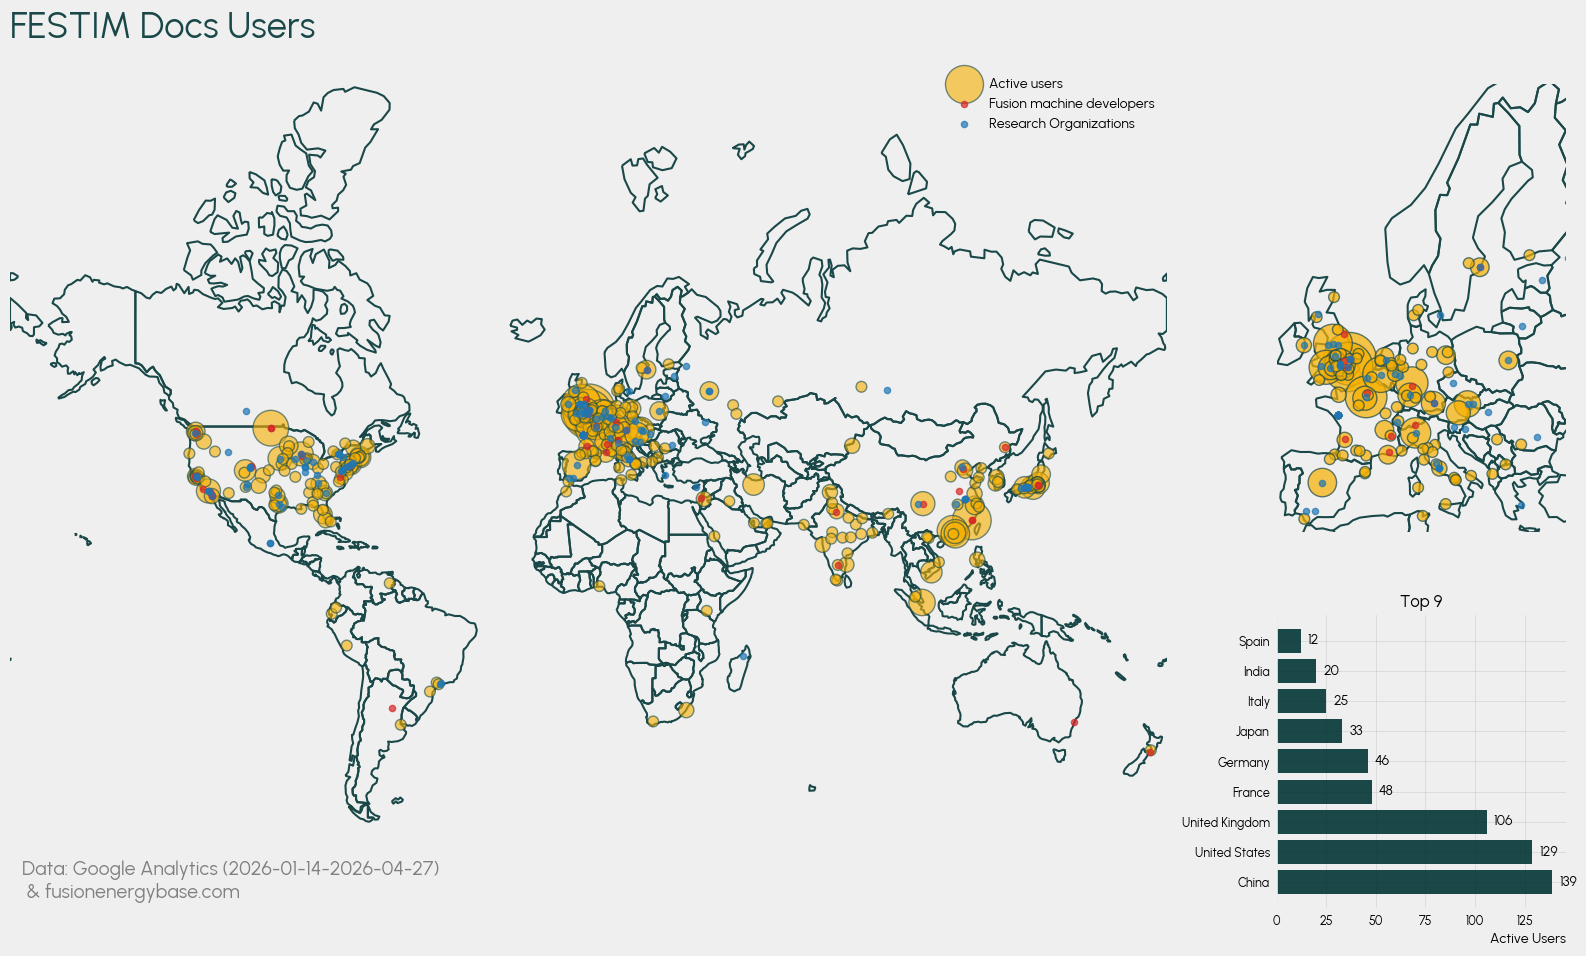

In [7]:
plot_map(
    data=df_users,
    locations=locations_users,
    metric="activeUsers",
    plot_fusion_orgs=True,
    plot_fusion_devs=True,
    s_factor=60,
    data_barchart=df_users_countries,
    data_barchart_x_metric="country",
)
plt.show()

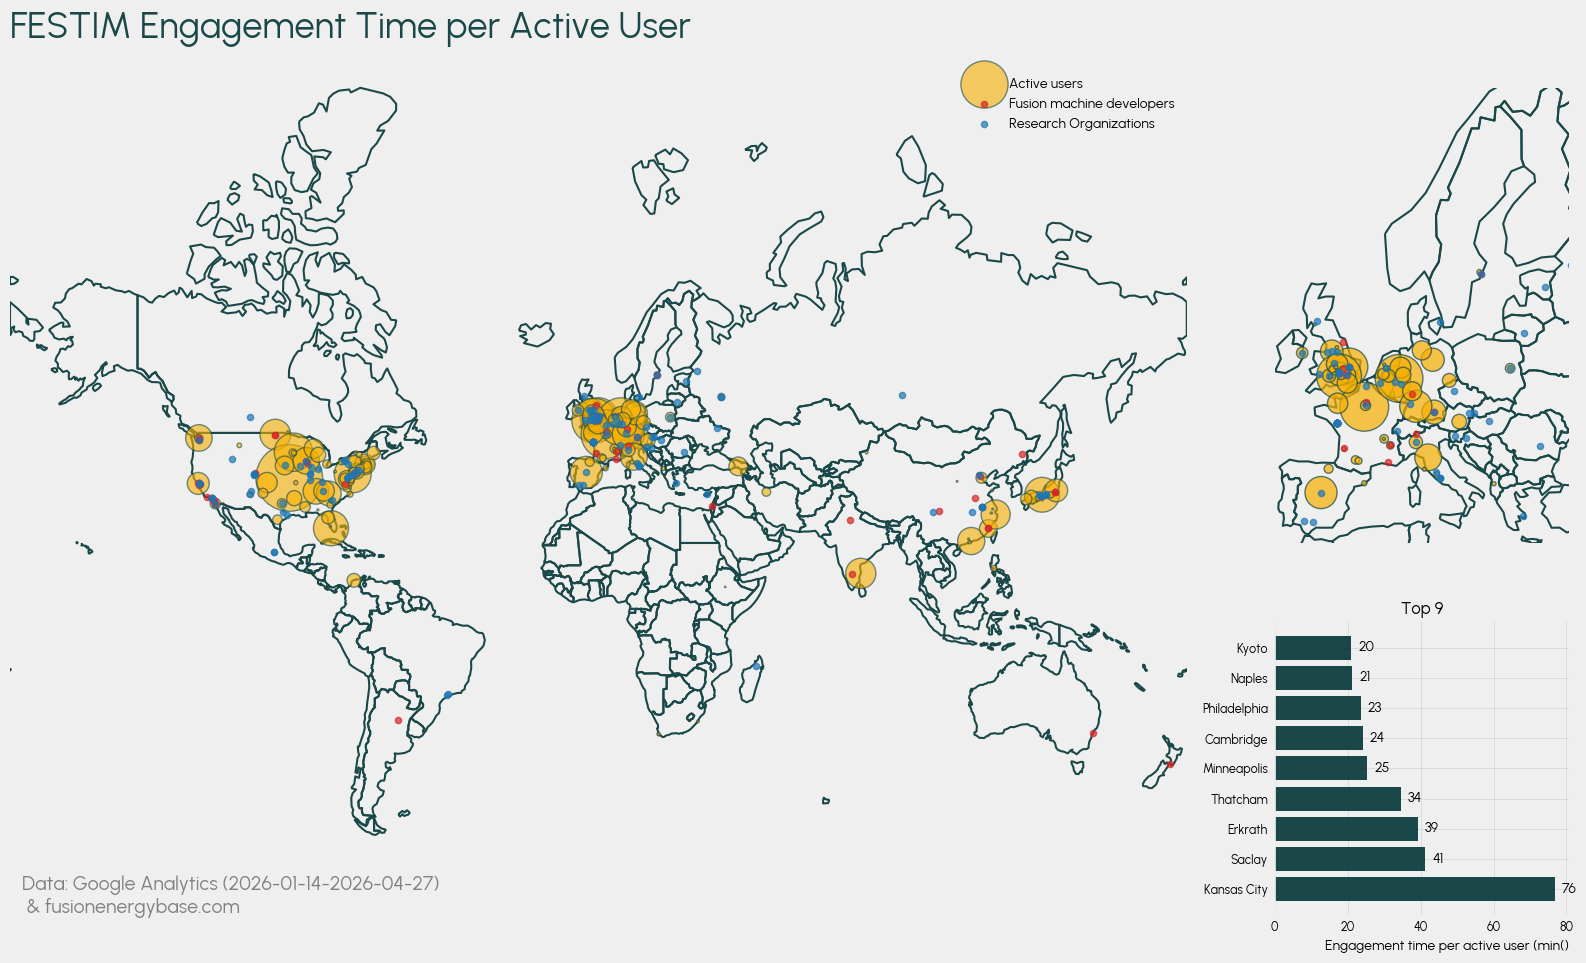

In [8]:
plot_map(
    data=df_tutorials,
    locations=locations_tutorials,
    metric="engagementTimePerActiveUser",
    plot_fusion_orgs=True,
    plot_fusion_devs=True,
    s_factor=30,
    data_barchart=df_tutorials,
    data_barchart_x_metric="city",
)
plt.show()

## Create timelapse
Transient map analysis can be implemented using iterative dates and FuncAnimation from matplotlib.

In [9]:
response_period = users_city(start_date_ga, end_date_ga, FESTIM_DOCS_ID)

data = pd.DataFrame(
    {
        "city": [row.dimension_values[0].value for row in response_period.rows],
        "activeUsers": [int(row.metric_values[0].value) for row in response_period.rows],
    }
)

data

,city,activeUsers
0,(not set),191
1,Cambridge,24
2,London,21
3,Paris,15
4,Manchester,13
...,...,...
281,Xi'An,1
282,Yantai,1
283,Zhuhai,1
284,Zhukovskiy,1


In [10]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import pandas as pd
import numpy as np

# 1. Define frequency ('D' for daily, 'W' for weekly, 'M' for monthly)
frequency = "W"
time_delta = {"D": 0, "W": 6, "M": 30}[frequency]  # Number of days in the period

# Generate date periods from our start to end date
periods = pd.date_range(start=start_date_ga, end=end_date_ga, freq=frequency)
period_starts = periods - pd.Timedelta(
    days=time_delta
)  # For weekly, we look at the 7-day period ending on each date

# 2. Fetch data cumulatively for each period
period_data = []
period_locs = []

print(f"Fetching {frequency} data from GA for {len(periods)} periods...")
for period_start, period_end in zip(period_starts, periods):
    # Cumulative active users from the start date up to the current period end
    response_period = users_city(period_start, period_end, FESTIM_DOCS_ID)

    df_period = pd.DataFrame(
        {
            "city": [row.dimension_values[0].value for row in response_period.rows],
            "activeUsers": [
                int(row.metric_values[0].value) for row in response_period.rows
            ],
        }
    )
    df_period = df_period[df_period["city"] != "(not set)"]

    # Geocode the cities found in this period's fetch
    locs_period = find_locations_from_cache(
        df_period, "locations_cache.geojson", update_cache=True
    )

    period_data.append(df_period)
    period_locs.append(locs_period)

print(f"Data fetching complete. Generating animation...")

Fetching W data from GA for 15 periods...
Data fetching complete. Generating animation...


In [11]:
from IPython.display import HTML

# 3. Set up the figure for animation
size_factor = 0.8
fig_anim = plt.figure(figsize=(15 * size_factor, 10 * size_factor))
ax_anim = fig_anim.add_subplot(1, 1, 1, projection=proj)
ax_anim.set_axis_off()

# background map
world.boundary.plot(ax=ax_anim, color="gray", linewidth=0.5)

# Prep the scatter object with empty data initially
scatter_plot = ax_anim.scatter(
    [], [], color="C1", edgecolors="C0", alpha=0.6, zorder=10
)
title_text = ax_anim.set_title(
    "", fontsize=20, fontweight="bold", loc="left", pad=20, color="C0"
)
pc = ccrs.PlateCarree()

plot_locations(
    locations_fusion_developers,
    pc,
    proj,
    color="tab:red",
    alpha=0.7,
    s=20,
    label="Fusion machine developers",
    zorder=11,
)



# 4. Define the update function for each frame
def update(frame):
    df_week = period_data[frame]
    locs_week = period_locs[frame]
    p_end = periods[frame]
    p_start = p_end - pd.Timedelta(days=time_delta)

    if not locs_week.empty:
        new_coords_anim = proj.transform_points(
            pc, locs_week.geometry.x, locs_week.geometry.y
        )
        scatter_plot.set_offsets(new_coords_anim[:, :2])
        # scale the bubble size
        scatter_plot.set_sizes(df_week["activeUsers"] * 60)
    else:
        scatter_plot.set_offsets(np.empty((0, 2)))
        scatter_plot.set_sizes([])

    title_text.set_text(
        f"FESTIM Docs Users (Active Since {p_start.strftime('%Y-%m-%d')} up to {p_end.strftime('%Y-%m-%d')})"
    )

    return scatter_plot, title_text


# 5. Create the animation
anim = FuncAnimation(fig_anim, update, frames=len(periods), interval=200, blit=False)

# Close the figure to prevent a static plot from showing below the animation
plt.close(fig_anim)

# 6. Display the animation inline
HTML(anim.to_jshtml())

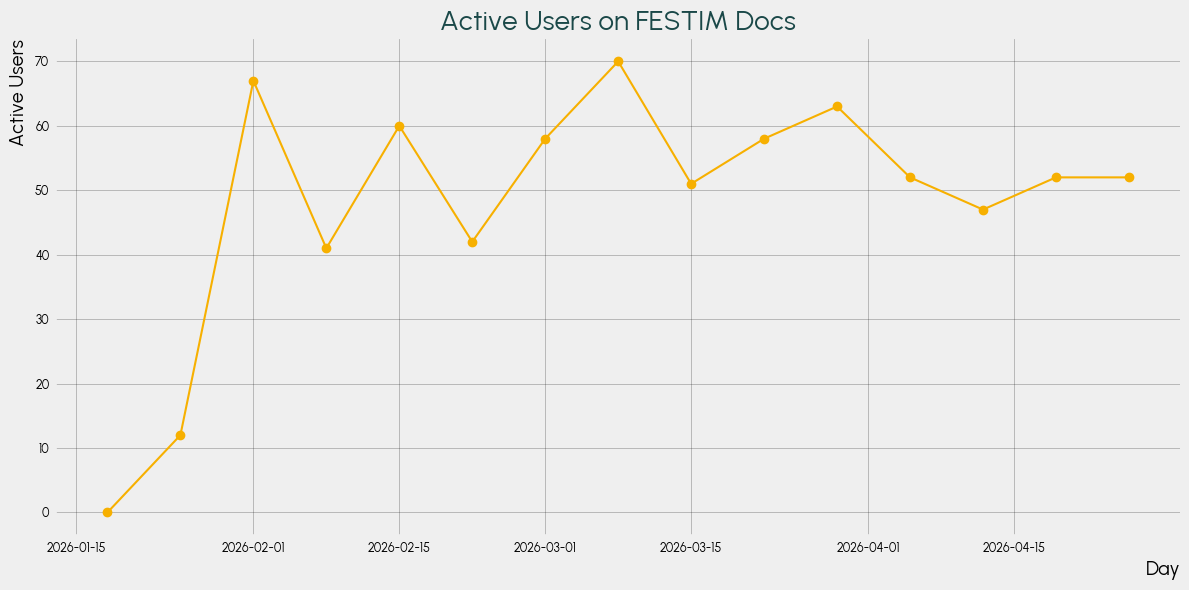

In [12]:
# Time series of active users per week
active_users = [df["activeUsers"].sum() for df in period_data]
plt.figure(figsize=(12, 6))
plt.plot(periods, active_users, marker="o", color="C1")
plt.title("Active Users on FESTIM Docs", fontsize=20, fontweight="bold", color="C0")
plt.xlabel("Day", fontsize=14)
plt.ylabel("Active Users", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Time evolution of users per country

In [13]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import pandas as pd
import numpy as np

# 1. Define frequency ('D' for daily, 'W' for weekly, 'M' for monthly)
frequency = "D"
time_delta = {"D": 0, "W": 6, "M": 30}[frequency]  # Number of days in the period

# Generate date periods from our start to end date
periods = pd.date_range(start=start_date_ga, end=end_date_ga, freq=frequency)
period_starts = periods - pd.Timedelta(
    days=time_delta
)  # For weekly, we look at the 7-day period ending on each date

# 2. Fetch data cumulatively for each period
period_data = []
period_locs = []

print(f"Fetching {frequency} data from GA for {len(periods)} periods...")
for period_start, period_end in zip(period_starts, periods):
    # Cumulative active users from the start date up to the current period end
    response_period = users_world(period_start, period_end, FESTIM_DOCS_ID)

    df_period = pd.DataFrame(
        {
            "country": [row.dimension_values[0].value for row in response_period.rows],
            "activeUsers": [
                int(row.metric_values[0].value) for row in response_period.rows
            ],
        }
    )

    period_data.append(df_period)

print(f"Data fetching complete. Generating animation...")

Fetching D data from GA for 104 periods...
Data fetching complete. Generating animation...


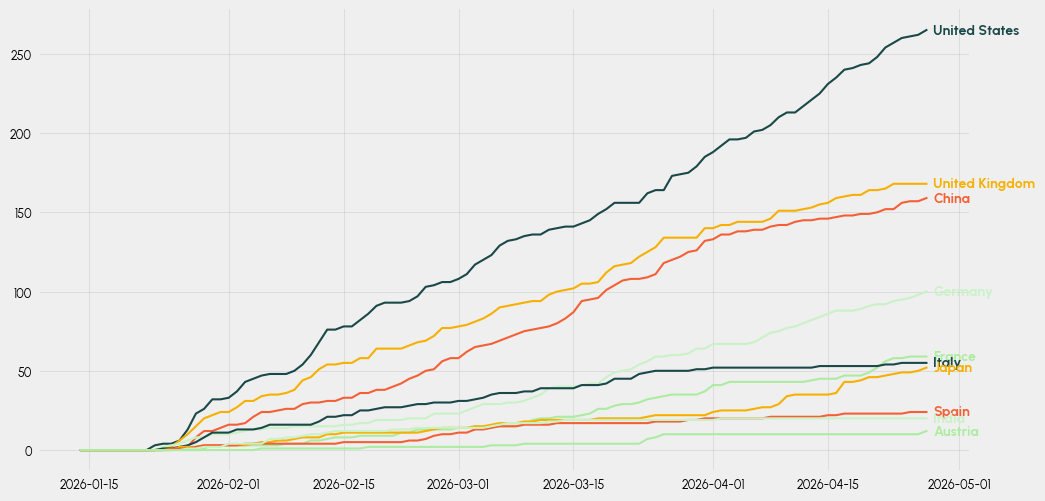

In [14]:
# plot time series of cumulative active users per week one line per country

plt.figure(figsize=(12, 6))

all_countries = set()
for df in period_data:
    all_countries.update(df["country"].unique())
all_countries = sorted(all_countries)

all_countries.remove("(not set)")  # remove (not set) if present

country_users = {country: [] for country in all_countries}
for country in all_countries:
    for df in period_data:
        if country in df["country"].values:
            country_users[country].append(df[df["country"] == country]["activeUsers"].values[0])
        else:
            country_users[country].append(0)

# sort countries by total users in the last period
countries_sorted = sorted(all_countries, key=lambda c: np.cumsum(country_users[c])[-1], reverse=True)
for country in countries_sorted[:10]:  # plot top countries
    cumul = np.cumsum(country_users[country])
    l, = plt.plot(periods, cumul, label=country)
    # add label at the end of line
    plt.annotate(
        country,
        xy=(periods[-1], cumul[-1]),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        color=l.get_color(),
        # bold
        font=bold_font,
    )

0     2026-01-14
1     2026-01-15
2     2026-01-16
3     2026-01-17
4     2026-01-18
         ...    
99    2026-04-23
100   2026-04-24
101   2026-04-25
102   2026-04-26
103   2026-04-27
Name: x, Length: 104, dtype: datetime64[us]

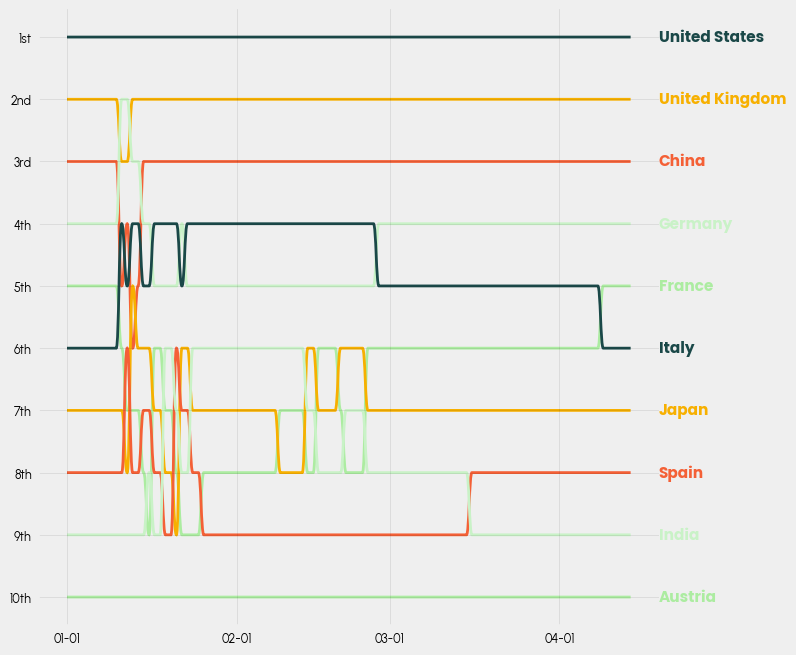

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

from bumplot import bumplot

# make dataframe from period data and cumulative users
df = pd.DataFrame(
    {
        "x": periods,
    }
)
for i, country in enumerate(countries_sorted):
    df[country] = np.cumsum(country_users[country])

fig, ax = plt.subplots(figsize=(8, 8))
_, bump_artists =bumplot(
    x="x",
    y_columns=countries_sorted[:10],
    data=df,
    curve_force=0.5,
    ordinal_labels=True,
    plot_kwargs={"lw": 2},
    scatter_kwargs={"s": 0, "ec": "black", "lw": 2},
    # colors=["#ffbe0b", "#ff006e", "#3a86ff"],
)

font_bold = load_google_font("Poppins", weight="bold")
for name, (_, scatter) in bump_artists.items():
    _, last_y = scatter.get_offsets()[-1]
    ax.text(
        x=1,
        y=last_y,
        s=name,
        size=11,
        color=scatter.get_facecolor(),
        va="center",
        ha="left",
        font=font_bold,
        transform=ax.get_yaxis_transform(),
    )

# x ticks only months
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))


df['x']